# Preço / Lucro Histórico - Itaúsa (ITSA4)
---
O índice Preço/Lucro (P/L) é um dos indicadores fundamentalistas mais utilizados na análise de ações. Ele expressa quantas vezes o mercado está disposto a pagar pelo lucro gerado por uma empresa, quanto menor o múltiplo, mais "barata" a ação em relação ao seu resultado.

Neste estudo, calculamos o P/L histórico da Itaúsa (ITSA4) combinando duas fontes de dados abertas:

- **CVM (Comissão de Valores Mobiliários):** dados contábeis das DFPs (Demonstrações Financeiras Padronizadas), especificamente o Lucro por Ação extraído da DRE consolidada.
- **Yahoo Finance:** série histórica de preços de fechamento e ajustados da ação ITSA4.SA.

O resultado é uma visão de longo prazo do múltiplo P/L da Itaúsa, com destaque para a média histórica como referência de valuation.

## Dependências e Configurações Iniciais

---

Carregamento das bibliotecas utilizadas no projeto e configuração do logger para rastreamento das etapas de execução.

In [2]:
import  tempfile
import  requests

from    zipfile     import ZipFile
from    pathlib     import Path
from    loguru      import logger

import  pandas              as pd
import  matplotlib.pyplot   as plt
import  yfinance            as yf

logger.info('BIBLIOTECAS CARREGADAS')

2026-06-11 10:23:46.260 | INFO     | __main__:<module>:12 - BIBLIOTECAS CARREGADAS


In [3]:
DATA            = Path().cwd()/'dados'
DATA.mkdir(parents=True, exist_ok=True)
logger.info('DIRETORIO PARA DADOS CRIADO')


URL_BASE        = 'https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS/'
ANO_INICIO      = 2010
ANO_FIM         = 2025
DEMONSTRATIVO   = 'DRE_con'
ARQUIVOS_ZIP    = [ f'dfp_cia_aberta_{ano}.zip' for ano in range(ANO_INICIO, ANO_FIM + 1) ]

logger.info('CONSTANTES CARREGADAS')

2026-06-11 11:15:39.210 | INFO     | __main__:<module>:3 - DIRETORIO PARA DADOS CRIADO
2026-06-11 11:15:39.240 | INFO     | __main__:<module>:12 - CONSTANTES CARREGADAS


## 1. Coleta de Arquivos na CVM

---

A CVM disponibiliza publicamente os dados das DFPs em arquivos `.zip` organizados por ano. Cada arquivo contém múltiplos CSVs referentes aos diferentes demonstrativos contábeis das companhias abertas listadas na B3.

O código abaixo realiza o download dos arquivos de 2010 a 2025, extrai os CSVs em um diretório temporário e os persiste localmente para uso nas etapas seguintes.

In [4]:
logger.info('Iniciando download e extração de arquivos CSVs')
logger.info(f'Total de arquivos em formato zip para download: {len(ARQUIVOS_ZIP)}')

# temp
with tempfile.TemporaryDirectory() as temp:
    temp_path = Path(temp)
    logger.debug(f'Pasta temporária criada em: {temp_path}')

    # loop para baixar e extrair 
    for arquivo in ARQUIVOS_ZIP:
        url_completa = URL_BASE + arquivo
        caminho_zip = temp_path / arquivo
        
        try:            
            logger.info(f'Baixando: {arquivo}')                             
            resposta = requests.get(url_completa, stream=True)       
            resposta.raise_for_status() 
            
            # arq em modo de escrita binária ('wb') e salva em pedaços (chunks)
            with open(caminho_zip, 'wb') as f:
                for chunk in resposta.iter_content(chunk_size=8192): 
                    if chunk: 
                        f.write(chunk)
            
            # extracao
            logger.info(f'Extraindo {arquivo}...')
            with ZipFile(caminho_zip, 'r') as zip_ref:
                zip_ref.extractall(DATA)
                
        except requests.exceptions.HTTPError as http_err:            
            logger.exception(f'Erro HTTP ao tentar baixar {arquivo}')
        except Exception as e:            
            logger.exception(f'Erro genérico ao processar {arquivo}')

logger.debug(f'Arquivos extraídos em: {DATA}')
logger.info('Processo Concluído com sucesso')

2026-06-11 11:28:43.983 | INFO     | __main__:<module>:1 - Iniciando download e extração de arquivos CSVs
2026-06-11 11:28:43.992 | INFO     | __main__:<module>:2 - Total de arquivos em formato zip para download: 16
2026-06-11 11:28:44.030 | DEBUG    | __main__:<module>:7 - Pasta temporária criada em: C:\Users\wsant\AppData\Local\Temp\tmp4bw08y5b
2026-06-11 11:28:44.033 | INFO     | __main__:<module>:15 - Baixando: dfp_cia_aberta_2010.zip
2026-06-11 11:28:46.806 | INFO     | __main__:<module>:26 - Extraindo dfp_cia_aberta_2010.zip...
2026-06-11 11:28:49.010 | INFO     | __main__:<module>:15 - Baixando: dfp_cia_aberta_2011.zip
2026-06-11 11:28:51.190 | INFO     | __main__:<module>:26 - Extraindo dfp_cia_aberta_2011.zip...
2026-06-11 11:28:52.818 | INFO     | __main__:<module>:15 - Baixando: dfp_cia_aberta_2012.zip
2026-06-11 11:28:54.607 | INFO     | __main__:<module>:26 - Extraindo dfp_cia_aberta_2012.zip...
2026-06-11 11:28:56.543 | INFO     | __main__:<module>:15 - Baixando: dfp_cia_

## 2. Carregando a DRE

---

Com os arquivos extraídos, filtramos apenas os CSVs referentes à **DRE consolidada** (`DRE_con`), que contém as contas de resultado das empresas. Em seguida, todos os arquivos são lidos e concatenados em um único DataFrame.

In [5]:
logger.info('Buscando arquivos CSV com DRE')

arquivos_csv     = list(DATA.glob('*.csv'))
arquivos_csv_dre = [arquivo for arquivo in arquivos_csv if DEMONSTRATIVO in arquivo.name]

if not arquivos_csv_dre:
    logger.warning('Nenhum arquivo csv com DRE encontrado.')

logger.info(f'Total de arquivos encontrados: {len(arquivos_csv_dre)}')

logger.info('Criando lista de dataframes')
lista_df = [
    pd.read_csv(arquivo, sep=';', encoding='ISO-8859-1', decimal=',', dtype=str) # dtype str :: evitar erro de tipos no concat
        for arquivo in arquivos_csv_dre
]

logger.info('Iniciar Concatenação')
df = pd.concat(lista_df, ignore_index=True)
logger.info(f'DataFrame concatenado, o dataset possui: {df.shape[0]} linhas e {df.shape[1]} colunas.')

2026-06-11 11:30:22.902 | INFO     | __main__:<module>:1 - Buscando arquivos CSV com DRE


2026-06-11 11:30:23.042 | INFO     | __main__:<module>:9 - Total de arquivos encontrados: 16
2026-06-11 11:30:23.043 | INFO     | __main__:<module>:11 - Criando lista de dataframes
2026-06-11 11:30:25.136 | INFO     | __main__:<module>:17 - Iniciar Concatenação
2026-06-11 11:30:25.176 | INFO     | __main__:<module>:19 - DataFrame concatenado, o dataset possui: 449570 linhas e 15 colunas.


In [14]:
df.head()

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
0,00.000.000/0001-91,2010-12-31,3,BCO BRASIL S.A.,001023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2009-01-01,2009-12-31,3.01,Receitas da Intermediação Financeira,67608506.0000000000,S
1,00.000.000/0001-91,2010-12-31,3,BCO BRASIL S.A.,001023,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2010-01-01,2010-12-31,3.01,Receitas da Intermediação Financeira,85143206.0000000000,S
2,00.000.000/0001-91,2010-12-31,3,BCO BRASIL S.A.,001023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2009-01-01,2009-12-31,3.01.01,Receita de Juros,67608506.0000000000,S
3,00.000.000/0001-91,2010-12-31,3,BCO BRASIL S.A.,001023,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2010-01-01,2010-12-31,3.01.01,Receita de Juros,85143206.0000000000,S
4,00.000.000/0001-91,2010-12-31,3,BCO BRASIL S.A.,001023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2009-01-01,2009-12-31,3.02,Despesas da Intermediação Financeira,-39302642.0000000000,S


## 3. Tratamento dos Dados

---

Antes de qualquer análise, ajustamos os tipos das colunas, datas e valores numéricos, que chegam como `string` para garantir compatibilidade nas operações seguintes.

Também filtramos apenas os registros com `ORDEM_EXERC == 'ÚLTIMO'`, mantendo somente o exercício mais recente reportado por cada empresa em cada período. Isso evita duplicações causadas por reapresentações e versões anteriores das demonstrações.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449570 entries, 0 to 449569
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CNPJ_CIA       449570 non-null  object
 1   DT_REFER       449570 non-null  object
 2   VERSAO         449570 non-null  object
 3   DENOM_CIA      449570 non-null  object
 4   CD_CVM         449570 non-null  object
 5   GRUPO_DFP      449570 non-null  object
 6   MOEDA          449570 non-null  object
 7   ESCALA_MOEDA   449570 non-null  object
 8   ORDEM_EXERC    449570 non-null  object
 9   DT_INI_EXERC   449570 non-null  object
 10  DT_FIM_EXERC   449570 non-null  object
 11  CD_CONTA       449570 non-null  object
 12  DS_CONTA       449570 non-null  object
 13  VL_CONTA       449570 non-null  object
 14  ST_CONTA_FIXA  449570 non-null  object
dtypes: object(15)
memory usage: 51.4+ MB


In [6]:
df = (df
    .assign(
        DT_REFER     = pd.to_datetime(df['DT_REFER']),
        DT_INI_EXERC = pd.to_datetime(df['DT_INI_EXERC']),
        DT_FIM_EXERC = pd.to_datetime(df['DT_FIM_EXERC']),
        VERSAO       = pd.to_numeric(df['VERSAO']),
        VL_CONTA     = pd.to_numeric(df['VL_CONTA']),
    )
)
df.dtypes

CNPJ_CIA                 object
DT_REFER         datetime64[ns]
VERSAO                    int64
DENOM_CIA                object
CD_CVM                   object
GRUPO_DFP                object
MOEDA                    object
ESCALA_MOEDA             object
ORDEM_EXERC              object
DT_INI_EXERC     datetime64[ns]
DT_FIM_EXERC     datetime64[ns]
CD_CONTA                 object
DS_CONTA                 object
VL_CONTA                float64
ST_CONTA_FIXA            object
dtype: object

In [17]:
df['ORDEM_EXERC'].unique()

array(['PENÚLTIMO', 'ÚLTIMO'], dtype=object)

In [7]:
df = df[ df['ORDEM_EXERC'] =='ÚLTIMO']

In [19]:
df['ORDEM_EXERC'].unique()

array(['ÚLTIMO'], dtype=object)

In [20]:
df.shape

(225197, 15)

## 4. Empresas Disponíveis

---

O dataset consolidado cobre um grande número de companhias abertas. Aqui fazemos uma inspeção inicial para identificar as empresas presentes e localizar o código CVM da empresa de interesse.

In [22]:
df.sample()

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
210620,08.534.605/0001-74,2018-12-31,1,RENOVA ENERGIA S.A. - EM RECUPERAÇÃO JUDICIAL,021636,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2018-01-01,2018-12-31,3.04.06.05,Outras receitas,0.0,N


In [23]:
df['DENOM_CIA'].drop_duplicates()

1                                           BCO BRASIL S.A.
78                               BRB BANCO DE BRASILIA S.A.
113                    CENTRAIS ELET BRAS S.A. - ELETROBRAS
199                  COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB
281                                          VBC ENERGIA SA
                                ...                        
438679    ELEA DIGITAL INFRAESTRUTURA E REDES DE TELECOM...
441651                                            B100 S.A.
441803                                           REVEE S.A.
442363                        TUPI ENERGIAS RENOVÁVEIS S.A.
442509             ORANJEBTC S.A. - EDUCAÇÃO E INVESTIMENTO
Name: DENOM_CIA, Length: 769, dtype: object

In [28]:
cols = ['CD_CVM','DENOM_CIA']
empresas = df[cols].drop_duplicates()
empresas = empresas.set_index('CD_CVM')

empresas

,DENOM_CIA
CD_CVM,
001023,BCO BRASIL S.A.
014206,BRB BANCO DE BRASILIA S.A.
002437,CENTRAIS ELET BRAS S.A. - ELETROBRAS
014451,COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB
014540,VBC ENERGIA SA
...,...
026948,ELEA DIGITAL INFRAESTRUTURA E REDES DE TELECOM...
027634,B100 S.A.
027650,REVEE S.A.


## 5. Selecionando a Itaúsa

---

Utilizamos uma busca textual para localizar a Itaúsa no cadastro de empresas e confirmar seu código CVM (`007617`). Em seguida, filtramos o DataFrame principal para trabalhar exclusivamente com os registros dessa companhia.

In [54]:
cia  = 'itaúsa'
mask = empresas['DENOM_CIA'].str.contains(cia, case=False, na=False)
empresas[ mask ]

,DENOM_CIA
CD_CVM,
007617,ITAÚSA S.A.


In [55]:
df[df['CD_CVM'] == '007617' ]['DENOM_CIA'].unique()

array(['ITAÚSA S.A.'], dtype=object)

In [56]:
dre = df[df['CD_CVM'] == '007617' ]

dre

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
20638,61.532.644/0001-15,2010-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2010-01-01,2010-12-31,3.01,Receita de Venda de Bens e/ou Serviços,5.240000e+06,S
20640,61.532.644/0001-15,2010-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2010-01-01,2010-12-31,3.02,Custo dos Bens e/ou Serviços Vendidos,-3.624000e+06,S
20642,61.532.644/0001-15,2010-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2010-01-01,2010-12-31,3.03,Resultado Bruto,1.616000e+06,S
20644,61.532.644/0001-15,2010-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2010-01-01,2010-12-31,3.04,Despesas/Receitas Operacionais,-1.583000e+07,S
20646,61.532.644/0001-15,2010-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2010-01-01,2010-12-31,3.04.01,Despesas com Vendas,0.000000e+00,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444671,61.532.644/0001-15,2025-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2025-01-01,2025-12-31,3.99.01.01,ON,1.477140e+00,N
444673,61.532.644/0001-15,2025-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2025-01-01,2025-12-31,3.99.01.02,PN,1.477140e+00,N
444675,61.532.644/0001-15,2025-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2025-01-01,2025-12-31,3.99.02,Lucro Diluído por Ação,0.000000e+00,N
444677,61.532.644/0001-15,2025-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2025-01-01,2025-12-31,3.99.02.01,ON,1.477140e+00,N


## 6. Contas Disponíveis na DRE

---

Antes de extrair o Lucro por Ação, inspecionamos as contas presentes na DRE da Itaúsa. Isso nos permite identificar o código correto da conta de interesse e verificar a estrutura do demonstrativo.

In [ ]:
contas_itausa = df \
    .loc[df['CD_CVM'] == '007617', ['CD_CONTA', 'DS_CONTA']] \
    .drop_duplicates() \
    .set_index("CD_CONTA")


contas_itausa

,DS_CONTA
CD_CONTA,
3.01,Receita de Venda de Bens e/ou Serviços
3.02,Custo dos Bens e/ou Serviços Vendidos
3.03,Resultado Bruto
3.04,Despesas/Receitas Operacionais
3.04.01,Despesas com Vendas
3.04.02,Despesas Gerais e Administrativas
3.04.03,Perdas pela Não Recuperabilidade de Ativos
3.04.04,Outras Receitas Operacionais
3.04.05,Outras Despesas Operacionais


## 7. Lucro por Ação (LPA)

---

Extraímos a conta `3.99.01.02`, que corresponde ao **Lucro Básico por Ação** nas DFPs. Os valores são indexados pela data de referência, formando a série temporal do LPA que será combinada com os preços de mercado.

In [79]:
# dre[dre['CD_CONTA'] == '3.99.01.02']
lpa = df \
        .loc[(df['CD_CVM'] == '007617') & (df['CD_CONTA'] == '3.99.01.02'), ['DT_REFER', 'VL_CONTA']] \
        .set_index('DT_REFER')
lpa

,VL_CONTA
DT_REFER,
2010-12-31,1.01000
2011-12-31,1.10000
2012-12-31,0.94000
2013-12-31,1.05000
2014-12-31,1.30000
2015-12-31,1.31000
2016-12-31,1.11000
2017-12-31,1.13000
2018-12-31,1.13000


## 8. Cotações Históricas - Yahoo Finance

---

Coletamos via `yfinance` os preços diários da ITSA4 desde 2011, incluindo o preço de fechamento (`Close`) e o preço ajustado por proventos (`Adj Close`). O ajuste é relevante para uma comparação mais fiel ao retorno efetivo do acionista ao longo do tempo.

In [118]:
precos = yf.download('ITSA4.SA', start='2011-01-01', end='2025-12-31',auto_adjust=False)
precos

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,ITSA4.SA,ITSA4.SA,ITSA4.SA,ITSA4.SA,ITSA4.SA,ITSA4.SA
Date,,,,,,
2011-01-03,2.115089,5.559474,5.631019,5.530014,5.551057,13756332
2011-01-04,2.154424,5.631019,5.631019,5.551057,5.588934,15090050
2011-01-05,2.181797,5.702564,5.702564,5.588934,5.593142,15180343
2011-01-06,2.135102,5.580516,5.681521,5.546848,5.681521,22463875
2011-01-07,2.072304,5.416384,5.593142,5.395341,5.563682,16553742
...,...,...,...,...,...,...
2025-12-22,11.320360,11.460000,11.510000,11.380000,11.500000,18783200
2025-12-23,11.448776,11.590000,11.640000,11.450000,11.500000,12528200


In [119]:
# precos[['Adj Close', 'Close']]
precos.columns = precos.columns.droplevel(1)
precos

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2011-01-03,2.115089,5.559474,5.631019,5.530014,5.551057,13756332
2011-01-04,2.154424,5.631019,5.631019,5.551057,5.588934,15090050
2011-01-05,2.181797,5.702564,5.702564,5.588934,5.593142,15180343
2011-01-06,2.135102,5.580516,5.681521,5.546848,5.681521,22463875
2011-01-07,2.072304,5.416384,5.593142,5.395341,5.563682,16553742
...,...,...,...,...,...,...
2025-12-22,11.320360,11.460000,11.510000,11.380000,11.500000,18783200
2025-12-23,11.448776,11.590000,11.640000,11.450000,11.500000,12528200
2025-12-26,11.458654,11.600000,11.620000,11.490000,11.510000,17144900


## 9. Calculando o P/L

---

Combinamos as duas séries:  preços e LPA , agora em um único DataFrame, propagando o LPA para os dias úteis em que não há novo dado contábil (`ffill`). O P/L é calculado dividindo o preço de fechamento pelo Lucro por Ação correspondente.

Calculamos duas versões do indicador:
- **P/L:** baseado no preço de fechamento bruto.
- **P/L Ajustado:** baseado no preço ajustado por proventos, oferecendo uma visão corrigida do múltiplo histórico.

In [120]:
indicadores = pd.concat(
        [precos[['Adj Close', 'Close']], lpa]
        , axis=1
    ).ffill().dropna().rename({'VL_CONTA':'LPA'}, axis=1)

indicadores['PL']           = indicadores['Close'] / indicadores['LPA']
indicadores['PL Ajustado']  = indicadores['Adj Close'] / indicadores['LPA']

indicadores

,Adj Close,Close,LPA,PL,PL Ajustado
2011-01-03,2.115089,5.559474,1.01000,5.504430,2.094147
2011-01-04,2.154424,5.631019,1.01000,5.575266,2.133093
2011-01-05,2.181797,5.702564,1.01000,5.646103,2.160195
2011-01-06,2.135102,5.580516,1.01000,5.525263,2.113962
2011-01-07,2.072304,5.416384,1.01000,5.362757,2.051787
...,...,...,...,...,...
2025-12-23,11.448776,11.590000,1.36291,8.503863,8.400244
2025-12-26,11.458654,11.600000,1.36291,8.511201,8.407492
2025-12-29,11.448776,11.590000,1.36291,8.503863,8.400244
2025-12-30,11.537680,11.680000,1.36291,8.569898,8.465474


## 10. P/L Histórico - Visualização

---

O gráfico abaixo apresenta a evolução do P/L da Itaúsa desde 2011, com as médias históricas tracejadas como referência. A comparação entre o P/L bruto e o ajustado evidencia o impacto dos proventos pagos ao longo do tempo na percepção do valuation da empresa.

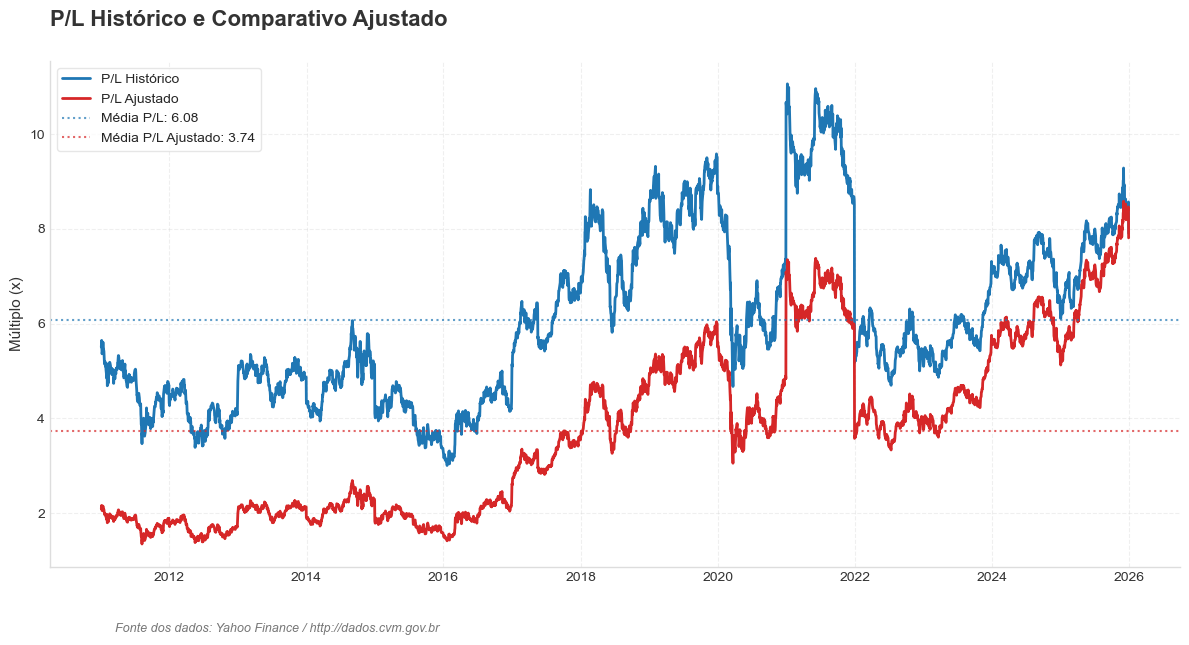

In [147]:
#estilo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 6.5)) 

#cores
COR_PL = '#1f77b4'       
COR_PL_AJ = '#d62728'    
COR_LINHAS = '#7f7f7f'   
COR_TEXTO = '#333333'    

#plotes
ax.plot(indicadores.index, indicadores['PL'], label='P/L Histórico', color=COR_PL, linewidth=2)
ax.plot(indicadores.index, indicadores['PL Ajustado'], label='P/L Ajustado', color=COR_PL_AJ, linewidth=2)

#medias
media_pl = indicadores['PL'].mean()
media_pl_aj = indicadores['PL Ajustado'].mean()

ax.axhline(media_pl, linestyle=':', color=COR_PL, alpha=0.7, linewidth=1.5,
           label=f'Média P/L: {media_pl:.2f}')
ax.axhline(media_pl_aj, linestyle=':', color=COR_PL_AJ, alpha=0.7, linewidth=1.5,
           label=f'Média P/L Ajustado: {media_pl_aj:.2f}')

#titulos e sub
ax.set_title('P/L Histórico e Comparativo Ajustado', pad=25, fontsize=16, fontweight='bold', color=COR_TEXTO, loc='left')
ax.set_ylabel('Múltiplo (x)', fontsize=11, color=COR_TEXTO)

#eixo e grade
ax.grid(True, linestyle='--', alpha=0.3, color='#cccccc')
ax.tick_params(axis='both', colors=COR_TEXTO, labelsize=10)

#remover bordas superior e direita
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

#legenda
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10)

#rodape ::figtext usa coordenadas relativas da imagem (0 a 1)
plt.figtext(0.1, 0.02, "Fonte dos dados: Yahoo Finance / http://dados.cvm.gov.br", 
            fontsize=9, color='#777777', style='italic')

#ajuste fino para não cortar o rodapé
plt.tight_layout()
plt.subplots_adjust(bottom=0.12) 

plt.show()
